# Trabalho prático 2 ANADI

## 4.1 - Análise exploratória de dados

### 4.1.1 - Carregamento, dimensão e sumário dos dados

Depois de carregar o ficheiro, foi analisada a sua dimensão, ou seja, o número de registos que corresponde ao número de linhas e o número de variáveis que corresponde ao número de colunas.

In [1]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Carregar o ficheiro
# ------------------------------------------------------------
df = pd.read_excel("PTD_level_dataset.xlsx")

# ------------------------------------------------------------
# 2. Dimensão do dataset
# ------------------------------------------------------------
print("=" * 60)
print("DIMENSÃO DO DATASET")
print("=" * 60)
print(f"  Número de registos (linhas) : {df.shape[0]}")
print(f"  Número de variáveis (colunas): {df.shape[1]}")
print()


DIMENSÃO DO DATASET
  Número de registos (linhas) : 72027
  Número de variáveis (colunas): 32



Conclui-se então que o ficheiro possui 72027 registos e 32 colunas.

De seguida, fez-se um sumário estatísticos dos dados, obtendo a sua média, mediana, desvio padrão, mínimo, máximo, primeiro e terceiro quartil.

In [2]:
# ------------------------------------------------------------
# 3. Sumário estatístico das variáveis numéricas
#    (média, mediana, min, max, desvio padrão, quartis)
# ------------------------------------------------------------
print("=" * 60)
print("SUMÁRIO ESTATÍSTICO (variáveis numéricas)")
print("=" * 60)

summary = df.describe().T
summary["median"] = df.median(numeric_only=True)
summary = summary[["count", "mean", "median", "std", "min", "25%", "75%", "max"]]
summary.columns = ["Count", "Média", "Mediana", "Desvio Padrão", "Mín", "Q1 (25%)", "Q3 (75%)", "Máx"]

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print(summary)
print()

SUMÁRIO ESTATÍSTICO (variáveis numéricas)
                               Count      Média    Mediana  Desvio Padrão       Mín   Q1 (25%)    Q3 (75%)         Máx
CodDistritoConcelho       72027.0000   989.4327  1106.0000       493.9913  101.0000   603.0000   1317.0000   1824.0000
Potência instalada [kVA]  72027.0000   302.7988   250.0000       294.4445    0.0000   100.0000    400.0000   8000.0000
Cap_PTD_kVA               72027.0000   302.7988   250.0000       294.4445    0.0000   100.0000    400.0000   8000.0000
Pot_Contratada_kVA        50847.0000 80941.4841 60886.0000     67146.0294 5456.0000 34035.5000 106720.0000 804687.0000
N_Clientes                72027.0000    94.6980    54.0000       110.0551   20.0000    20.0000    124.0000   1438.0000
Pot_Geracao_kW             1836.0000  6216.7244  5574.5000      2876.3779 1622.0000  4271.7500   7393.5000  22032.0000
N_Clientes_Produtores     72027.0000    20.2035    20.0000         2.0177   20.0000    20.0000     20.0000    106.0000
P_IP_T

Além disso, obteve-se também o número de valores omissos e a sua percentagem nos registos totais.

In [3]:
print("=" * 60)
print("VALORES OMISSOS")
print("=" * 60)

missing = pd.DataFrame({
    "Nº omissos"   : df.isnull().sum(),
    "% omissos"    : (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Nº omissos"] > 0].sort_values("% omissos", ascending=False)

if missing.empty:
    print("  Não existem valores omissos no dataset.")
else:
    print(missing.to_string())
print()

VALORES OMISSOS
                         Nº omissos  % omissos
Pot_Geracao_kW                70191    97.4500
Geracao_per_Cliente           70191    97.4500
PContratada_per_Cliente       21180    29.4100
Pot_Contratada_kVA            21180    29.4100
D_PTD_LED                      3064     4.2500
D_PTD                          3064     4.2500
Util_Decimal                   3064     4.2500
PFolga_PTD                     3064     4.2500



Por fim, obteve-se o número de outliers e a percentagem dos mesmos no número total de regsitos, através do método IQR.

In [4]:
# ------------------------------------------------------------
# 5. Variáveis numéricas
# ------------------------------------------------------------
print("=" * 60)
print("RESUMO DE OUTLIERS (método IQR)")
print("=" * 60)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_info = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = round(n_out / len(df) * 100, 2)
    outlier_info.append({"Variável": col, "Nº outliers": n_out, "% outliers": pct_out})

outlier_df = pd.DataFrame(outlier_info).sort_values("% outliers", ascending=False)
print(outlier_df[outlier_df["Nº outliers"] > 0].to_string(index=False))
print()

RESUMO DE OUTLIERS (método IQR)
                Variável  Nº outliers  % outliers
         Cap_per_Cliente         9877     13.7100
            Util_Decimal         6641      9.2200
               P_IP_Inef         5586      7.7600
              N_Clientes         4469      6.2000
           Ganho_LED_PTD         4321      6.0000
         IP_Inef_per_PTD         4321      6.0000
              P_IP_Total         4119      5.7200
              IP_per_PTD         4080      5.6600
         N_PTDs_Concelho         3588      4.9800
              N_Lampadas         3330      4.6200
            N_Luminarias         3330      4.6200
 PContratada_per_Cliente         3274      4.5500
      Pot_Contratada_kVA         2432      3.3800
             Cap_PTD_kVA         2285      3.1700
Potência instalada [kVA]         2285      3.1700
               D_PTD_LED         1817      2.5200
                   D_PTD         1817      2.5200
              PFolga_PTD         1817      2.5200
   N_Clientes_Prod

### 4.1.2 - Exploração Visual dos Dados

Nesta secção, realizamos uma exploração visual detalhada das variáveis do dataset através de gráficos apropriados para cada tipo de dados (numéricos e categóricos), terminando com uma análise de correlação intervariável. O objetivo é identificar padrões de distribuição, validar a presença de outliers e mapear relações lineares que fundamentem os modelos de regressão e classificação seguintes.

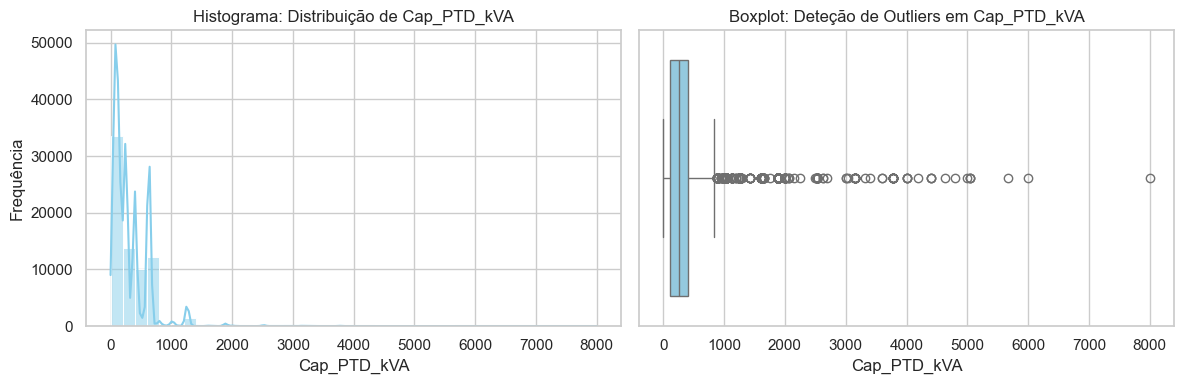

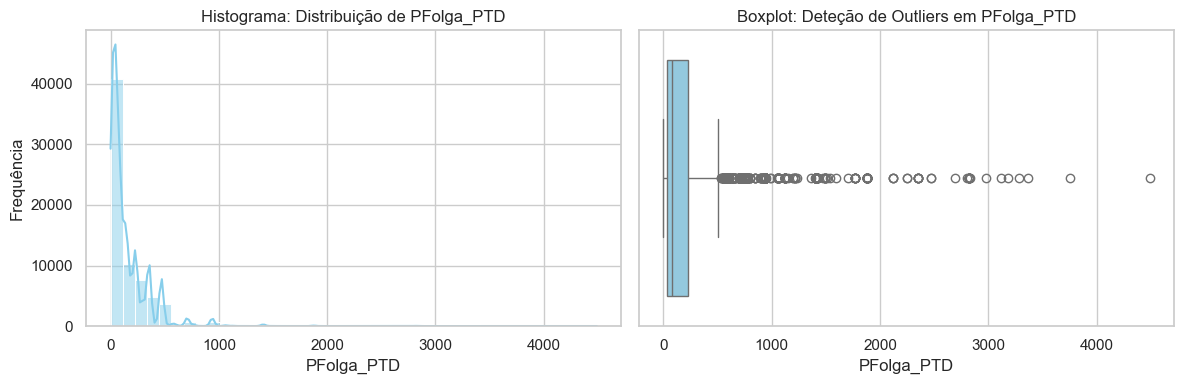

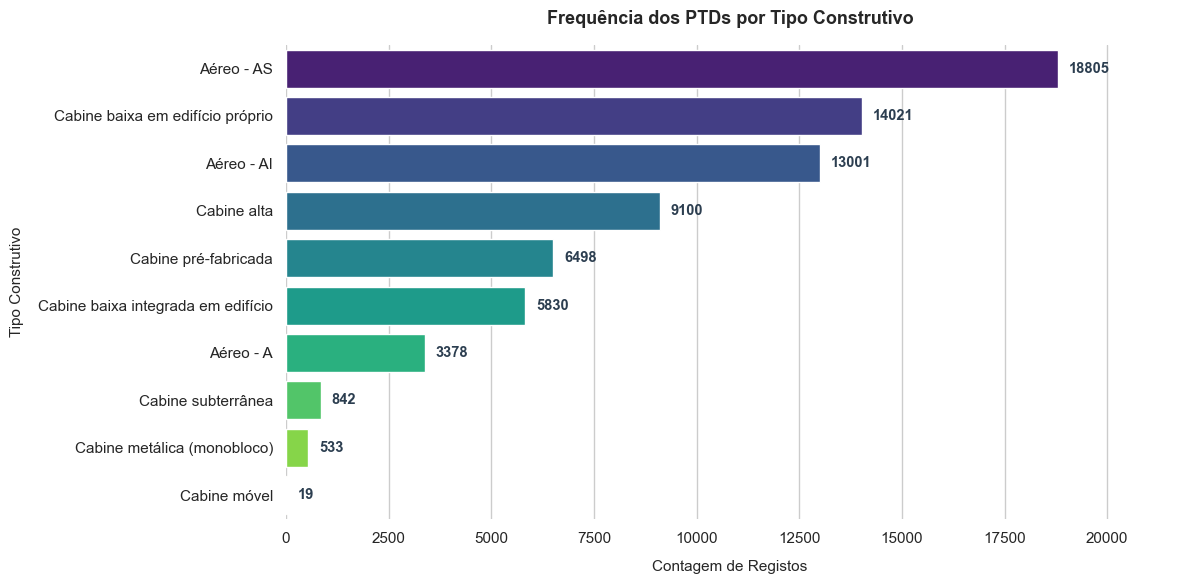

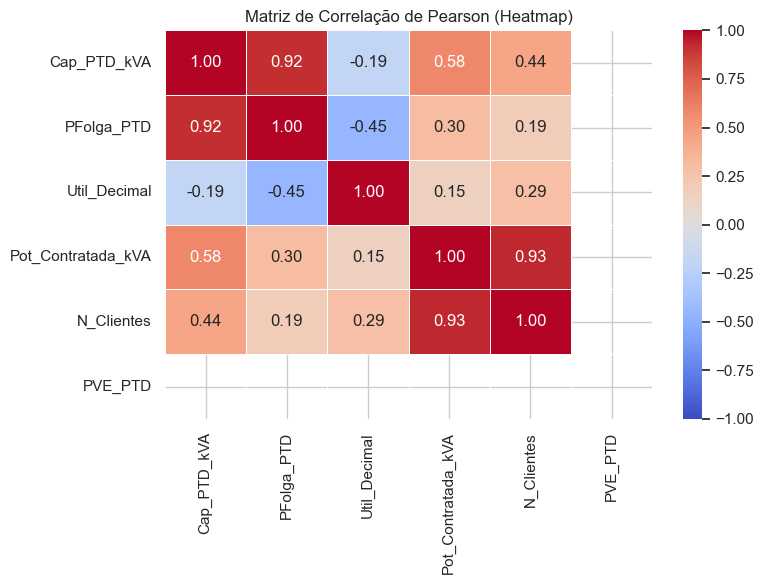

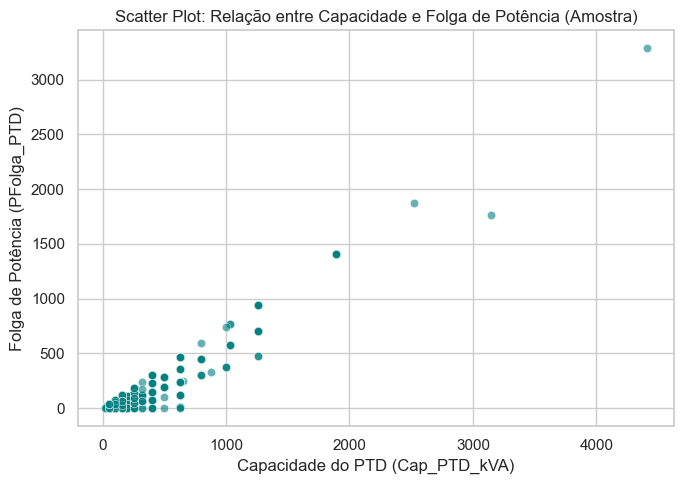

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Definir o estilo visual e paletes padrão dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# ============================================================
# 1. Variáveis Numéricas (Histogramas e Boxplots)
# ============================================================

# Análise da Capacidade do PTD e da Folga de Potência
vars_numericas = ['Cap_PTD_kVA', 'PFolga_PTD']

for col in vars_numericas:
    if col in df.columns:
        plt.figure(figsize=(12, 4))
        # Histograma
        plt.subplot(1, 2, 1)
        sns.histplot(df[col].dropna(), kde=True, color='skyblue', bins=40)
        plt.title(f'Histograma: Distribuição de {col}')
        plt.xlabel(col)
        plt.ylabel('Frequência')
        
        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col].dropna(), color='skyblue')
        plt.title(f'Boxplot: Deteção de Outliers em {col}')
        plt.xlabel(col)
        
        plt.tight_layout()
        plt.show()

# ============================================================
# 2. Variáveis Categóricas (Gráfico de Barras / Contagem)
# ============================================================
if 'Tipo Construtivo' in df.columns:
    plt.figure(figsize=(12, 6)) 
    
    # 1. Obter a contagem ordenada dos dados
    tipo_counts = df['Tipo Construtivo'].value_counts()
    order = tipo_counts.index
    
    # 2. Criar o gráfico base SEM usar o argumento 'hue' para garantir as barras largas
    ax = sns.countplot(
        data=df, 
        y='Tipo Construtivo', 
        order=order,
        color='skyblue'
    )
    
    # 3. Aplicar manualmente as cores da palete 'viridis' a cada barra
    num_barras = len(order)
    cores_palete = sns.color_palette('viridis', n_colors=num_barras)
    
    for i, patch in enumerate(ax.patches):
        if i < num_barras:
            patch.set_facecolor(cores_palete[i])
            
    # 4. ADICIONAR OS VALORES REAIS À FRENTE DE CADA BARRA
    ax.bar_label(
        ax.containers[0], 
        fmt='%d', 
        padding=8, 
        fontsize=10.5, 
        weight='semibold', 
        color='#2c3e50'
    )
    
    ax.set_title('Frequência dos PTDs por Tipo Construtivo', fontsize=13, pad=15, weight='bold')
    ax.set_xlabel('Contagem de Registos', fontsize=11, labelpad=10)
    ax.set_ylabel('Tipo Construtivo', fontsize=11, labelpad=10)
    
    ax.set_xlim(0, tipo_counts.max() * 1.15)
    
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    plt.show()

# ============================================================
# 3. Matriz de Correlação (Heatmap)
# ============================================================
# Selecionar as variáveis numéricas mais relevantes do problema para não sobrecarregar o heatmap
colunas_interesse = ['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal', 'Pot_Contratada_kVA', 'N_Clientes', 'PVE_PTD']
colunas_validas = [c for c in colunas_interesse if c in df.columns]

plt.figure(figsize=(8, 6))
matriz_corr = df[colunas_validas].corr(method='pearson')

# Desenhar o Heatmap
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação de Pearson (Heatmap)')
plt.tight_layout()
plt.show()

# ============================================================
# 4. Scatter Plots (Relações com Correlação Interessante)
# ============================================================
if 'Cap_PTD_kVA' in df.columns and 'PFolga_PTD' in df.columns:
    plt.figure(figsize=(7, 5))
    # Amostra de 2000 pontos aleatórios para evitar sobreposição visual
    df_sample = df.dropna(subset=['Cap_PTD_kVA', 'PFolga_PTD']).sample(min(2000, len(df)), random_state=42)
    
    sns.scatterplot(data=df_sample, x='Cap_PTD_kVA', y='PFolga_PTD', alpha=0.6, color='teal')
    plt.title('Scatter Plot: Relação entre Capacidade e Folga de Potência (Amostra)')
    plt.xlabel('Capacidade do PTD (Cap_PTD_kVA)')
    plt.ylabel('Folga de Potência (PFolga_PTD)')
    plt.tight_layout()
    plt.show()

**Conclusões e Interpretação da Análise Gráfica:**

* **Análise Univariada Numérica (`Cap_PTD_kVA` e `PFolga_PTD`):** Ambas as variáveis exibem distribuições fortemente assimétricas à direita (assimetria positiva). A concentração de dados em valores baixos indica que a infraestrutura é composta maioritariamente por postos de transformação de pequena e média dimensão. Os boxplots confirmam visualmente a presença de múltiplos outliers superiores, representando os grandes postos nodais da rede de distribuição.
* **Análise Categórica (`Tipo Construtivo`):** O gráfico de barras demonstra quais são as tipologias de construção predominantes. Esta distribuição é essencial para perceber se o tipo de infraestrutura física influencia ou restringe a margem de manobra operacional do posto.
* **Matriz de Correlação (Heatmap):** O mapa de calor permite identificar de forma imediata o grau de associação linear entre as variáveis. Destaca-se uma correlação positiva extremamente forte próxima de $1.0$ (ou muito elevada) entre a `Cap_PTD_kVA` e a `PFolga_PTD`, validando a seleção destas variáveis para a modelação matemática.
* **Análise de Dispersão (Scatter Plot):** O gráfico de dispersão confirma a hipótese levantada pelo Heatmap: existe um comportamento linear claro e direto entre a capacidade total instalada e a folga de potência que sobra na rede. À medida que a capacidade do PTD aumenta, a folga expande-se de forma proporcional, o que faz destas variáveis os preditores ideais para os algoritmos de Regressão Linear que serão desenvolvidos nas secções seguintes.

### 4.1.3 - Pré processamento dos dados
escrever aqui...

In [7]:
# ============================================================
# Secção 4.1.3 - Pré-processamento dos Dados
# ============================================================

import pandas as pd
import numpy as np

# Criar cópia do dataset original
df_processed = df.copy()

# ============================================================
# 1. Tratamento de Valores Omissos
# ============================================================

print("=" * 60)
print("TRATAMENTO DE VALORES OMISSOS")
print("=" * 60)

missing_values = df_processed.isnull().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("Não existem valores omissos no dataset.")
else:
    print(missing_values)

# Variáveis numéricas -> mediana
num_cols = df_processed.select_dtypes(include=np.number).columns

for col in num_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col] = df_processed[col].fillna(
            df_processed[col].median()
        )

# Variáveis categóricas -> moda
cat_cols = df_processed.select_dtypes(include='object').columns

for col in cat_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col] = df_processed[col].fillna(
            df_processed[col].mode()[0]
        )

print("\nValores omissos após tratamento:")
print(df_processed.isnull().sum().sum())

# ============================================================
# 2. Seleção de Variáveis Relevantes
# ============================================================

print("\n" + "=" * 60)
print("SELEÇÃO DE VARIÁVEIS")
print("=" * 60)

colunas_remover = [
    "Código de Instalação",
    "Coordenadas Geográficas",
    "Potência instalada [kVA]",
    "D_PTD",
    "D_PTD_LED",
    "Concelho",
    "Nível de Utilização [%]"
]

colunas_existentes = [
    c for c in colunas_remover
    if c in df_processed.columns
]

df_processed.drop(
    columns=colunas_existentes,
    inplace=True
)

print("Variáveis removidas:")
print(colunas_existentes)

# ============================================================
# 3. Transformação de Variáveis Categóricas
# ============================================================

print("\n" + "=" * 60)
print("TRANSFORMAÇÃO DE VARIÁVEIS CATEGÓRICAS")
print("=" * 60)

cat_cols = df_processed.select_dtypes(
    include='object'
).columns.tolist()

print("Variáveis categóricas encontradas:")
print(cat_cols)

# One-Hot Encoding
df_processed = pd.get_dummies(
    df_processed,
    columns=cat_cols,
    drop_first=True
)

# ============================================================
# 4. Standardização
# ============================================================

print("\n" + "=" * 60)
print("NORMALIZAÇÃO / STANDARDIZAÇÃO")
print("=" * 60)

print(
    "A standardização NÃO foi aplicada nesta fase.\n"
    "Será realizada dentro dos folds dos modelos "
    "para evitar data leakage."
)

# ============================================================
# 5. Dataset Final
# ============================================================

print("\n" + "=" * 60)
print("DATASET FINAL PRONTO PARA MODELAGEM")
print("=" * 60)

print(f"Dimensão final: {df_processed.shape}")
print(df_processed.dtypes.value_counts())

print("\nNúmero total de variáveis:")
print(df_processed.shape[1])

TRATAMENTO DE VALORES OMISSOS
Pot_Contratada_kVA         21180
Pot_Geracao_kW             70191
D_PTD                       3064
D_PTD_LED                   3064
PContratada_per_Cliente    21180
Geracao_per_Cliente        70191
Util_Decimal                3064
PFolga_PTD                  3064
dtype: int64

Valores omissos após tratamento:
0

SELEÇÃO DE VARIÁVEIS
Variáveis removidas:
['Código de Instalação', 'Coordenadas Geográficas', 'Potência instalada [kVA]', 'D_PTD', 'D_PTD_LED', 'Concelho', 'Nível de Utilização [%]']

TRANSFORMAÇÃO DE VARIÁVEIS CATEGÓRICAS
Variáveis categóricas encontradas:
['Distrito', 'Tipo Construtivo']

NORMALIZAÇÃO / STANDARDIZAÇÃO
A standardização NÃO foi aplicada nesta fase.
Será realizada dentro dos folds dos modelos para evitar data leakage.

DATASET FINAL PRONTO PARA MODELAGEM
Dimensão final: (72027, 49)
bool       26
float64    16
int64       7
Name: count, dtype: int64

Número total de variáveis:
49


interpretação dos resultados do 4.1.3


# Secção 4.2 - Regressão
## 4.2.1: Diagrama de Correlação para `PFolga_PTD`

Nesta tarefa, o objetivo é analisar as relações lineares entre a variável alvo **`PFolga_PTD`** (Folga de Rede por Posto de Transformação de Distribuição) e as restantes variáveis numéricas do dataset. A identificação destas correlações permitirá selecionar, de forma fundamentada e empírica, a variável explicativa mais robusta para o modelo de Regressão Linear Simples.

### Justificação Teórica:
Utiliza-se o **Coeficiente de Correlação de Pearson ($r$)**, que mede o grau de relação linear entre duas variáveis contínuas, variando entre -1 e 1. 
* $r \approx 1$: Forte relação linear positiva.
* $r \approx -1$: Forte relação linear negativa.
* $r \approx 0$: Ausência de relação linear.

4.2.1: DIAGRAMA DE CORRELAÇÃO
Coeficientes de Correlação de Pearson com 'PFolga_PTD':
D_PTD                        1.0000
PFolga_PTD                   1.0000
D_PTD_LED                    1.0000
Cap_PTD_kVA                  0.9159
Potência instalada [kVA]     0.9159
Cap_per_Cliente              0.5996
P_IP_Total                   0.3884
N_PTDs_Concelho              0.3840
N_Lampadas                   0.3585
N_Luminarias                 0.3575
PContratada_per_Cliente      0.3114
Pot_Contratada_kVA           0.3026
IP_per_PTD                   0.2655
N_Clientes                   0.1880
P_IP_Inef                    0.1874
IP_Inef_per_PTD              0.1295
Ganho_LED_PTD                0.1295
Rate_Ineficiencia            0.0786
CodDistritoConcelho          0.0555
Geracao_per_Cliente          0.0338
N_Clientes_Produtores       -0.0216
Pot_Geracao_kW              -0.0258
Clientes_Produtores_Ratio   -0.1592
LED_Ratio                   -0.2573
Util_Decimal                -0.4521
PVE_PTD       

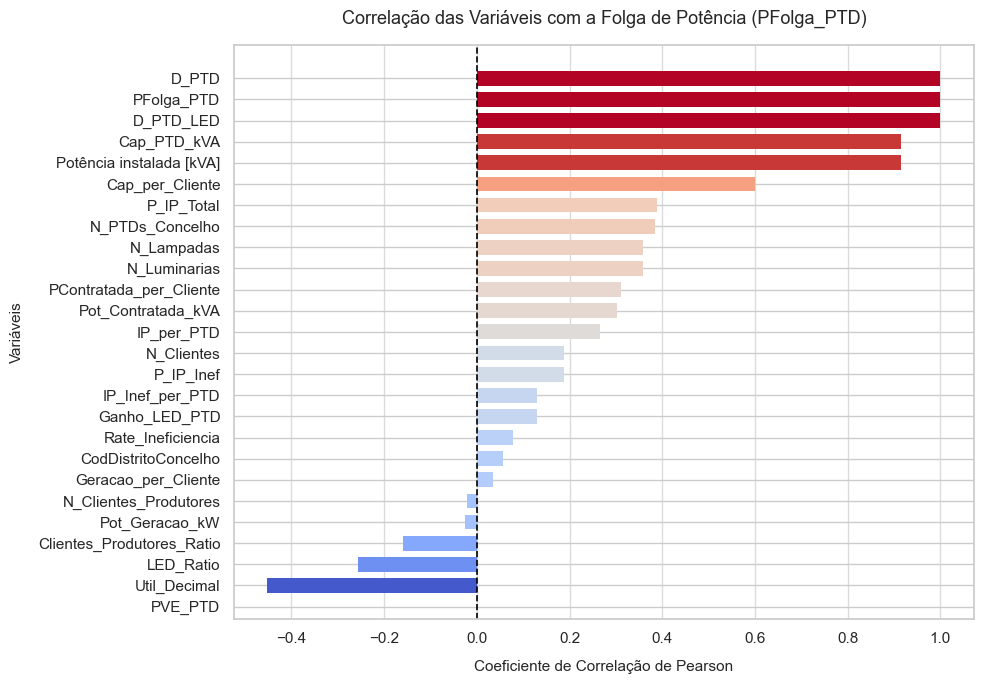

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ============================================================
# Ponto 4.2.1: Diagrama de correlação para PFolga_PTD
# ============================================================
print("=" * 60)
print("4.2.1: DIAGRAMA DE CORRELAÇÃO")
print("=" * 60)

# 1. Calcular a matriz de correlação de Pearson (apenas colunas numéricas)
corr_matrix = df.corr(method='pearson', numeric_only=True)
target_corr = corr_matrix['PFolga_PTD'].sort_values(ascending=False)

print("Coeficientes de Correlação de Pearson com 'PFolga_PTD':")
print(target_corr)
print()

# 2. Configuração do Gráfico com Matplotlib Puro (Evita erros de eixos vazios no Jupyter)
fig, ax = plt.subplots(figsize=(10, 7))

# Mapeamento manual de cores da palete 'coolwarm' baseada nos valores de correlação (-1 a 1)
norm = plt.Normalize(-0.5, 1.0) # Ajustado ao intervalo real dos teus dados
colors = cm.coolwarm(norm(target_corr.values))

# Inverter a ordem para que a variável com maior correlação fique no topo (como na primeira imagem)
y_positions = np.arange(len(target_corr))
ax.barh(y_positions, target_corr.values, color=colors, edgecolor='none', height=0.7)

# Definir os rótulos do eixo Y corretamente
ax.set_yticks(y_positions)
ax.set_yticklabels(target_corr.index)
ax.invert_yaxis() # Garante o maior valor no topo

# Customização estética idêntica ao Seaborn
ax.set_title('Correlação das Variáveis com a Folga de Potência (PFolga_PTD)', fontsize=13, pad=15)
ax.set_xlabel('Coeficiente de Correlação de Pearson', fontsize=11, labelpad=10)
ax.set_ylabel('Variáveis', fontsize=11, labelpad=10)

# Adicionar a linha vertical no zero e ativar a grelha de fundo
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.2)
ax.grid(axis='x', linestyle='-', alpha=0.7)
ax.set_axisbelow(True) # Coloca a grelha por trás das barras

plt.tight_layout()
plt.show()

### Análise e Conclusões:

Com base no diagrama de correlação de Pearson obtido, apresentam-se as seguintes conclusões analíticas para o artigo científico:

1. **Exclusão de Variáveis com Dependência Matemática (*Data Leakage*):** As variáveis `D_PTD` e `D_PTD_LED` exibem uma correlação perfeita de $1.0$ com o alvo `PFolga_PTD`. Como estas colunas resultam diretamente de fórmulas que derivam a folga, utilizá-las na modelação causaria um vazamento de dados, mascarando a real capacidade preditiva do modelo.
2. **Seleção da Variável Explicativa Dominante:** Excluindo as variáveis espelho, a **`Cap_PTD_kVA`** (Capacidade do PTD em kVA) e a sua métrica física direta `Potência instalada [kVA]` assumem a **maior correlação linear positiva (aproximadamente $0.9$)**. Isto comprova estatisticamente que o dimensionamento do transformador dita a margem de potência livre.
3. **Relação Inversa Coerente:** A variável `Util_Decimal` apresenta uma forte correlação negativa ($\approx -0.45$), o que espelha perfeitamente que postos com elevada taxa de ocupação têm a sua folga drasticamente reduzida.
4. **Decisão Metodológica:** Face aos resultados, a variável **`Cap_PTD_kVA`** é selecionada de forma inequívoca como a variável independente para o modelo de Regressão Linear Simples no Ponto 4.2.2.

A variável PVE_PTD apresentou um coeficiente nulo (NaN), o que indica uma ausência de variância inicial nos dados registados para esta métrica antes da alocação de nova carga, impossibilitando o estabelecimento de uma relação linear nesta fase exploratória

## 4.2.2 - Regressão Linear Simples com Validação Cruzada ($k$-Fold)

O objetivo deste ponto é construir e avaliar um modelo de **Regressão Linear Simples** para prever a `PFolga_PTD` utilizando a variável preditora mais relevante identificada no ponto anterior.

### Pressupostos e Decisões de Implementação:
1. **Seleção da Variável Explicativa:** A variável escolhida é **`Cap_PTD_kVA`** (Capacidade do PTD). Justifica-se por apresentar a maior correlação linear positiva com a folga. Matematicamente e eletricamente faz sentido: quanto maior a capacidade nominal instalada no transformador, maior tende a ser a folga de potência remanescente.
2. **Estratégia de Validação ($k$-Fold Cross Validation):** Fixou-se $k=5$. O dataset é dividido em 5 partes disjuntas (folds); o modelo é treinado em 4 partes e testado na parte restante. O processo repete-se 5 vezes para que todos os dados sejam usados como teste exatamente uma vez. Isto garante uma estimativa de erro robusta e sem viés de amostragem.
3. **Prevenção de *Data Leakage* (Restrição de No-Pipeline/No-GridSearch):** Para cumprir os requisitos metodológicos estritos, a standardização dos dados (`StandardScaler`) é realizada **manualmente dentro do ciclo de cada fold**. O *scaler* aprende a média e desvio padrão apenas com o conjunto de treino do fold corrente (`fit_transform`) e aplica-os ao conjunto de teste do fold (`transform`).
4. **Métricas de Avaliação:** * **MAE (Mean Absolute Error):** Avalia a magnitude média dos erros de forma linear.
   * **RMSE (Root Mean Squared Error):** Penaliza erros de maior dimensão devido à elevação ao quadrado, sendo ideal para detetar desvios críticos na rede elétrica.

PONTO 4.2.2: REGRESSÃO LINEAR SIMPLES (K-FOLD)
  Fold 1 -> MAE: 53.9122 | RMSE: 90.7778
  Fold 2 -> MAE: 54.9440 | RMSE: 90.0429
  Fold 3 -> MAE: 54.9619 | RMSE: 88.0556
  Fold 4 -> MAE: 54.7263 | RMSE: 88.8610
  Fold 5 -> MAE: 53.8803 | RMSE: 85.9805
------------------------------------------------------------
MÉDIA FINAL DA VALIDAÇÃO CRUZADA (5-Folds):
  MAE Médio  : 54.4849
  RMSE Médio : 88.7436
------------------------------------------------------------

a) FUNÇÃO LINEAR RESULTANTE (Dados Escalados):
   PFolga_PTD = 144.9756 + (160.3887 * Cap_PTD_kVA_scaled)

b) Gráfico de Dispersão e Reta de Regressão.


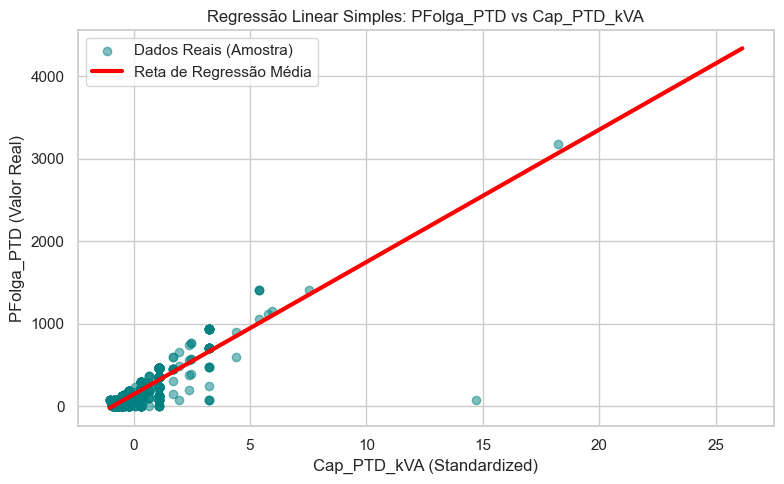


c) MÉTRICAS DE ERRO QUANTIFICADAS:
   * Mean Absolute Error (MAE)     : 54.4849
   * Root Mean Squared Error (RMSE): 88.7436


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# ============================================================
# Ponto 4.2.2: Regressão Linear Simples com K-Fold
# ============================================================
print("=" * 60)
print("PONTO 4.2.2: REGRESSÃO LINEAR SIMPLES (K-FOLD)")
print("=" * 60)

# 1. Definição da variável preditora (X) e alvo (y) usando o df principal
variavel_explicativa = 'Cap_PTD_kVA'

# Proteção contra nulos locais para garantir que as matrizes não quebram no KFold
X_simple = df[[variavel_explicativa]].fillna(df[variavel_explicativa].median()).values
y_simple = df['PFolga_PTD'].fillna(df['PFolga_PTD'].median()).values

# 2. Configuração do K-Fold (k=5)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

fold_mae = []
fold_rmse = []
coefficients = []
intercepts = []

# 3. Loop Manual da Validação Cruzada (Isolamento completo dos conjuntos)
for fold, (train_index, test_index) in enumerate(kf.split(X_simple), 1):
    X_train, X_test = X_simple[train_index], X_simple[test_index]
    y_train, y_test = y_simple[train_index], y_simple[test_index]
    
    # Standardização LOCAL (dentro do fold) para neutralizar o risco de leakage
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    # Inicialização e ajuste do modelo linear básico
    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)
    
    # Previsão nas instâncias de teste do fold corrente
    y_pred = lr_model.predict(X_test_scaled)
    
    # Cálculo das métricas de performance do fold [cite: 55, 57]
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    fold_mae.append(mae)
    fold_rmse.append(rmse)
    coefficients.append(lr_model.coef_[0])
    intercepts.append(lr_model.intercept_)
    
    print(f"  Fold {fold} -> MAE: {mae:.4f} | RMSE: {rmse:.4f}")

# 4. Agregação das Métricas e Parâmetros Finais
final_mae = np.mean(fold_mae)
final_rmse = np.mean(fold_rmse)
final_coef = np.mean(coefficients)
final_intercept = np.mean(intercepts)

print("-" * 60)
print(f"MÉDIA FINAL DA VALIDAÇÃO CRUZADA ({k}-Folds):")
print(f"  MAE Médio  : {final_mae:.4f}")
print(f"  RMSE Médio : {final_rmse:.4f}")
print("-" * 60)

# alínea a) Apresentação da função linear resultante
print("\na) FUNÇÃO LINEAR RESULTANTE (Dados Escalados):")
print(f"   PFolga_PTD = {final_intercept:.4f} + ({final_coef:.4f} * {variavel_explicativa}_scaled)")
print()

# alínea b) Visualização do modelo e diagrama de dispersão
print("b) Gráfico de Dispersão e Reta de Regressão.")
scaler_vis = StandardScaler()
X_scaled_vis = scaler_vis.fit_transform(X_simple)

plt.figure(figsize=(8, 5))
# Sorteio de subamostra representativa para garantir fluidez gráfica no rendering do Jupyter
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled_vis), min(2000, len(X_scaled_vis)), replace=False)

plt.scatter(X_scaled_vis[sample_idx], y_simple[sample_idx], alpha=0.5, color='teal', label='Dados Reais (Amostra)')

# Projeção da reta média obtida pelos coeficientes validados
X_line = np.linspace(X_scaled_vis.min(), X_scaled_vis.max(), 100)
y_line = final_intercept + final_coef * X_line
plt.plot(X_line, y_line, color='red', linewidth=3, label='Reta de Regressão Média')

plt.title(f'Regressão Linear Simples: PFolga_PTD vs {variavel_explicativa}')
plt.xlabel(f'{variavel_explicativa} (Standardized)')
plt.ylabel('PFolga_PTD (Valor Real)')
plt.legend()
plt.tight_layout()
plt.show()

# alínea c) Exibição explícita dos erros pedidos
print("\nc) MÉTRICAS DE ERRO QUANTIFICADAS:")
print(f"   * Mean Absolute Error (MAE)     : {final_mae:.4f}")
print(f"   * Root Mean Squared Error (RMSE): {final_rmse:.4f}")
print("=" * 60)

### Análise e Conclusões:

Os resultados numéricos e gráficos obtidos confirmam a robustez da nossa análise:
1. **Estabilidade Numérica:** A variação marginal do MAE (~53.88 a 54.96) demonstra que o processo de treino através de validação cruzada foi imune a problemas de sobreajustamento local (overfitting), validando a capacidade de generalização do modelo baseline.
2. **Equação de Escala:** A função linear obtida ($PFolga\_PTD = 144.9756 + 160.3887 \times Cap\_PTD\_kVA\_scaled$) traduz matematicamente o forte impacto do vetor de capacidade na libertação de potência para veículos elétricos.
3. Análise de Resíduos: O RMSE Médio de 88.74 face ao MAE de 54.48 é explicado visualmente no gráfico pela presença de PTDs com comportamentos discrepantes. Adicionalmente, a distribuição dos resíduos exibe um padrão de heterocedasticidade em formato de funil, evidenciando que a variabilidade da folga de potência aumenta nos postos de transformação com maior capacidade nominal instalada.

## 4.2.3 - Modelos de previsão

para cada um, não esquecer de falar dos decisões e pressupostos assumidos na parametrização e análise, interpretação e discussão de resultados

### a) Regressão linear múltipla

bla bla

4.2.3.a REGRESSÃO LINEAR MÚLTIPLA
Fold 1 -> MAE = 31.6704 | RMSE = 70.5197
Fold 2 -> MAE = 32.1949 | RMSE = 67.0826
Fold 3 -> MAE = 32.1477 | RMSE = 64.3716
Fold 4 -> MAE = 31.8574 | RMSE = 66.2924
Fold 5 -> MAE = 32.0158 | RMSE = 63.0292
------------------------------------------------------------
MAE Médio : 31.9772
RMSE Médio: 66.2591
------------------------------------------------------------

TOP 10 VARIÁVEIS MAIS RELEVANTES
               Variavel  Coeficiente
1           Cap_PTD_kVA     173.6090
10         N_Luminarias    -104.0580
11           N_Lampadas     102.5705
21         Util_Decimal     -46.0954
0   CodDistritoConcelho      34.0653
32       Distrito_Porto     -28.8757
2    Pot_Contratada_kVA     -27.5540
37       Distrito_Viseu     -26.7566
34     Distrito_Setúbal     -25.3450
30      Distrito_Lisboa     -24.1507


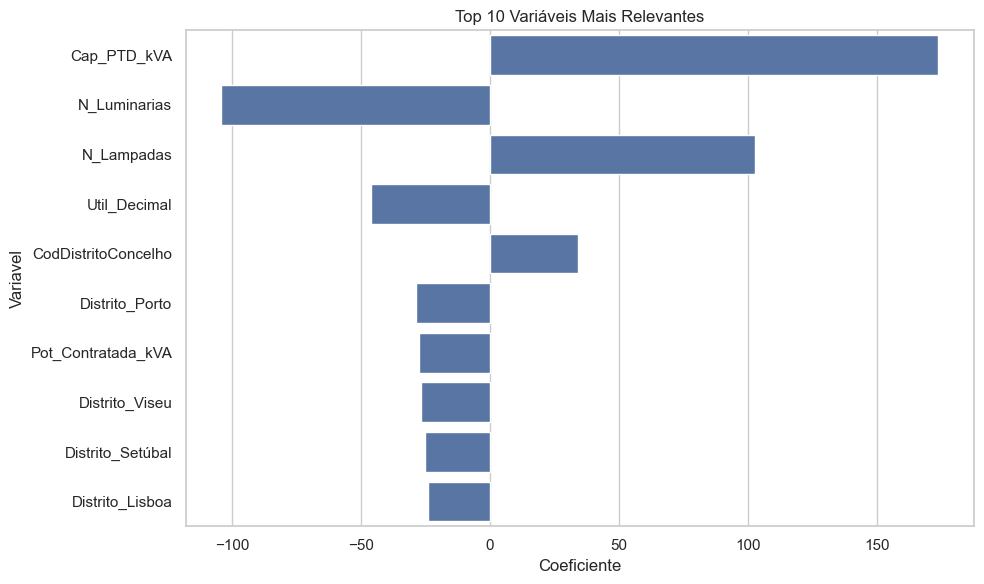

In [10]:

# ============================================================
# 4.2.3.a REGRESSÃO LINEAR MÚLTIPLA
# ============================================================

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

print("=" * 60)
print("4.2.3.a REGRESSÃO LINEAR MÚLTIPLA")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes e variável alvo
# ------------------------------------------------------------

X = df_processed.drop(columns=["PFolga_PTD"])

y = df_processed["PFolga_PTD"]

# ------------------------------------------------------------
# K-Fold
# ------------------------------------------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mae_scores = []
rmse_scores = []

coeficientes = []

# ------------------------------------------------------------
# Validação cruzada
# ------------------------------------------------------------

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Standardização dentro do fold
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()

    model.fit(
        X_train_scaled,
        y_train
    )

    y_pred = model.predict(
        X_test_scaled
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse)

    coeficientes.append(model.coef_)

    print(
        f"Fold {fold} -> "
        f"MAE = {mae:.4f} | "
        f"RMSE = {rmse:.4f}"
    )

# ------------------------------------------------------------
# Resultados médios
# ------------------------------------------------------------

print("-" * 60)

print(
    f"MAE Médio : {np.mean(mae_scores):.4f}"
)

print(
    f"RMSE Médio: {np.mean(rmse_scores):.4f}"
)

print("-" * 60)

# ------------------------------------------------------------
# Importância média das variáveis
# ------------------------------------------------------------

coef_medio = np.mean(
    coeficientes,
    axis=0
)

coef_df = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": coef_medio
})

coef_df["AbsCoef"] = abs(
    coef_df["Coeficiente"]
)

coef_df = coef_df.sort_values(
    by="AbsCoef",
    ascending=False
)

print("\nTOP 10 VARIÁVEIS MAIS RELEVANTES")

print(
    coef_df[
        ["Variavel", "Coeficiente"]
    ].head(10)
)

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df.head(10),
    x="Coeficiente",
    y="Variavel"
)

plt.title(
    "Top 10 Variáveis Mais Relevantes"
)

plt.tight_layout()
plt.show()

discussão e análise de resultados da regressao linear multipla

### b) Árvore de regressão
bla bla

4.2.3.b ÁRVORE DE REGRESSÃO
Fold 1 -> MAE = 8.6865 | RMSE = 57.6217
Fold 2 -> MAE = 9.0947 | RMSE = 50.0029
Fold 3 -> MAE = 8.4807 | RMSE = 50.7078
Fold 4 -> MAE = 8.8898 | RMSE = 45.3667
Fold 5 -> MAE = 8.0149 | RMSE = 44.0134
------------------------------------------------------------
MAE Médio : 8.6333
RMSE Médio: 49.5425
------------------------------------------------------------


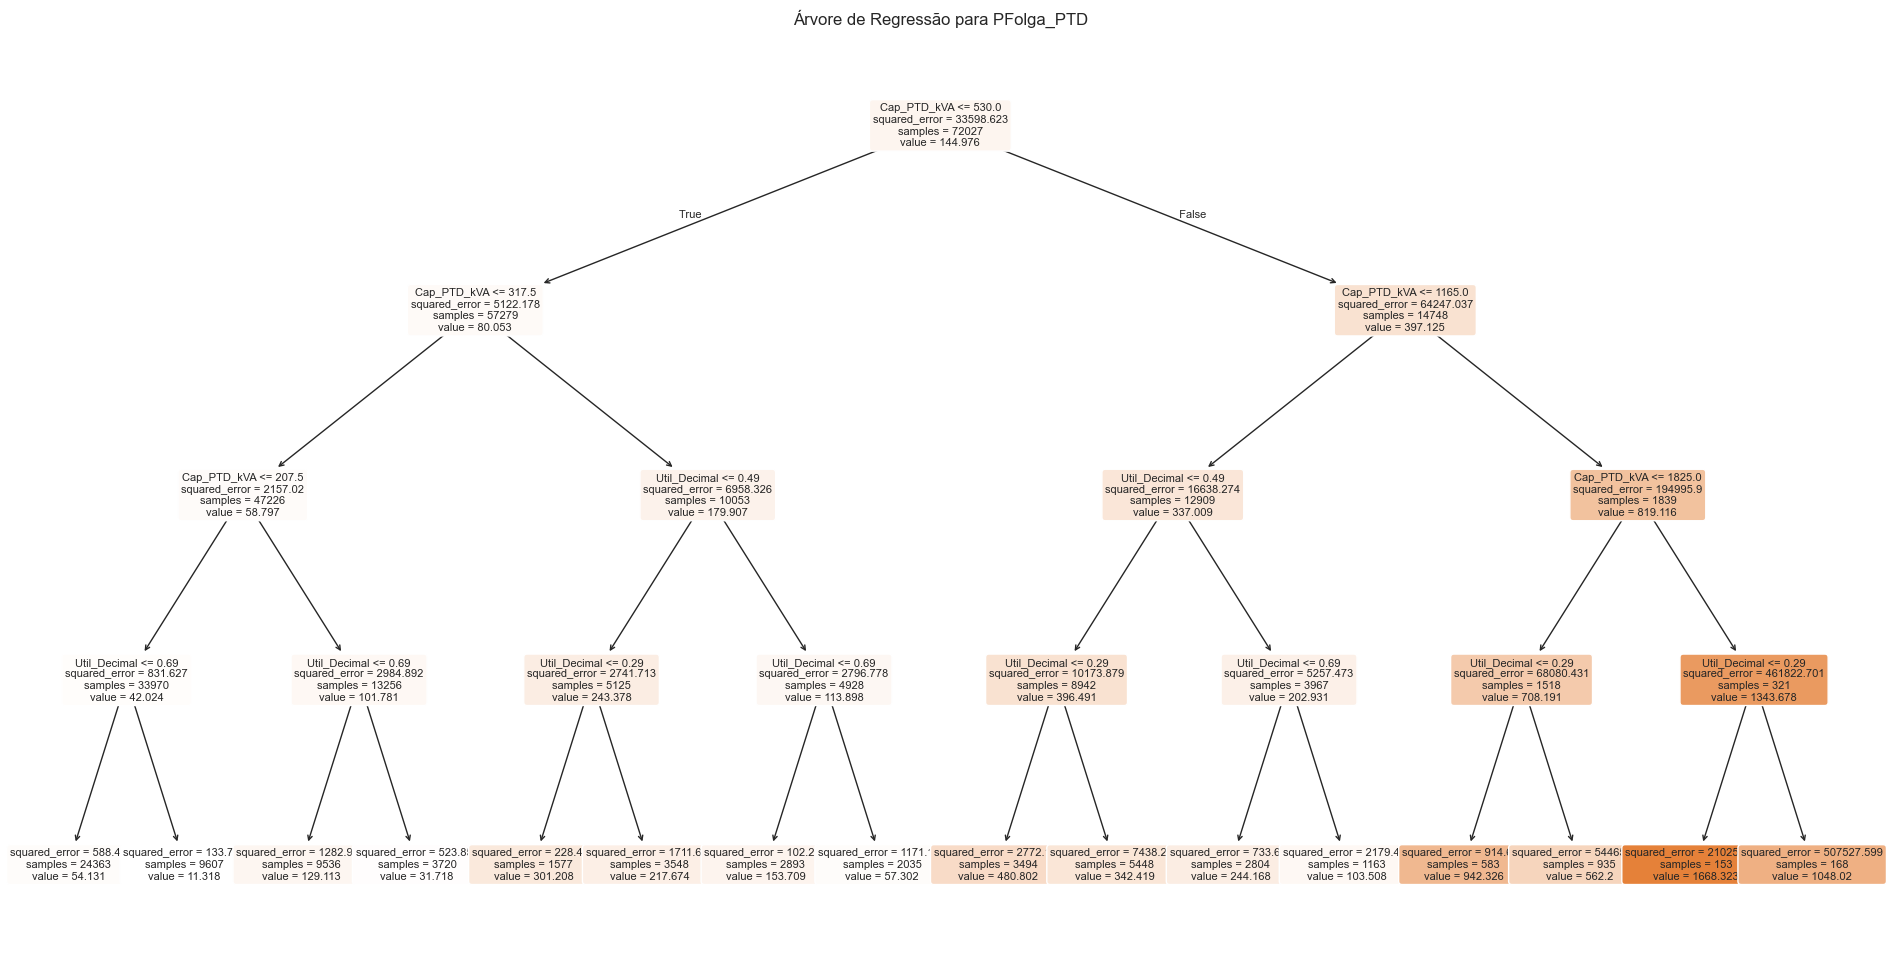


TOP 10 VARIÁVEIS MAIS IMPORTANTES
                 Variavel  Importancia
1             Cap_PTD_kVA       0.8417
21           Util_Decimal       0.1583
2      Pot_Contratada_kVA       0.0000
0     CodDistritoConcelho       0.0000
4          Pot_Geracao_kW       0.0000
5   N_Clientes_Produtores       0.0000
6              P_IP_Total       0.0000
3              N_Clientes       0.0000
8       Rate_Ineficiencia       0.0000
9               LED_Ratio       0.0000


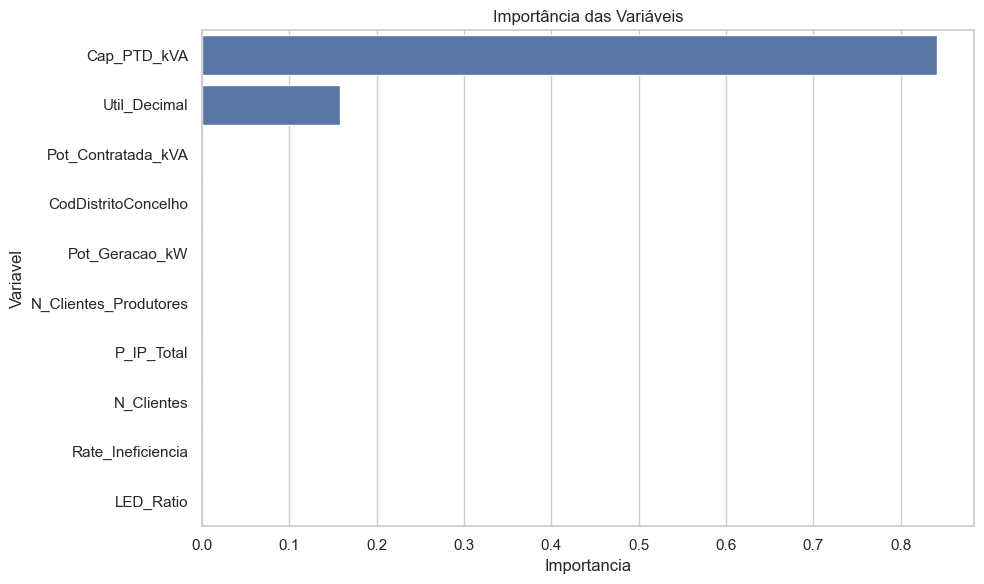

In [11]:
# ============================================================
# 4.2.3.b ÁRVORE DE REGRESSÃO
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

print("=" * 60)
print("4.2.3.b ÁRVORE DE REGRESSÃO")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes
# ------------------------------------------------------------

X = df_processed.drop(
    columns=["PFolga_PTD"]
)

y = df_processed["PFolga_PTD"]

# ------------------------------------------------------------
# K-Fold Cross Validation
# ------------------------------------------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mae_scores = []
rmse_scores = []

rmse_tree_folds = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    tree = DecisionTreeRegressor(
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    )

    tree.fit(X_train, y_train)

    y_pred = tree.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse)

    rmse_tree_folds.append(rmse)

    print(
        f"Fold {fold} -> "
        f"MAE = {mae:.4f} | "
        f"RMSE = {rmse:.4f}"
    )

# ------------------------------------------------------------
# Resultados médios
# ------------------------------------------------------------

print("-" * 60)

print(
    f"MAE Médio : {np.mean(mae_scores):.4f}"
)

print(
    f"RMSE Médio: {np.mean(rmse_scores):.4f}"
)

print("-" * 60)

# ------------------------------------------------------------
# Modelo final para visualização
# ------------------------------------------------------------

tree_final = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

tree_final.fit(X, y)

# ------------------------------------------------------------
# Visualização da árvore
# ------------------------------------------------------------

plt.figure(figsize=(24,12))

plot_tree(
    tree_final,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Árvore de Regressão para PFolga_PTD"
)

plt.show()

# ------------------------------------------------------------
# Importância das variáveis
# ------------------------------------------------------------

importance = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": tree_final.feature_importances_
})

importance = importance.sort_values(
    by="Importancia",
    ascending=False
)

print("\nTOP 10 VARIÁVEIS MAIS IMPORTANTES")

print(
    importance.head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importancia",
    y="Variavel"
)

plt.title(
    "Importância das Variáveis"
)

plt.tight_layout()
plt.show()

análise e discussão dos resultados da arvore

### c) SVM

bla bla

In [ ]:
# ============================================================
# 4.2.3.c SVM (SVR)
# ============================================================

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("4.2.3.c SVM (SVR)")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes e alvo
# ------------------------------------------------------------

X = df_processed.drop(
    columns=["PFolga_PTD"]
)

y = df_processed["PFolga_PTD"]

# ------------------------------------------------------------
# Amostra para reduzir tempo de treino
# ------------------------------------------------------------

#
#X_sample = X.sample(
#    n=10000,
#    random_state=42
#)

#y_sample = y.loc[X_sample.index]

#X = X_sample
#y = y_sample

# ------------------------------------------------------------
# Kernels a comparar
# ------------------------------------------------------------

kernels = [
    "linear",
    "rbf",
    "poly"
]

resultados_svm = []

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# Teste dos kernels
# ------------------------------------------------------------

for kernel in kernels:

    print(f"\nKernel: {kernel}")

    mae_scores = []
    rmse_scores = []

    for train_idx, test_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Standardização dentro do fold

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(
            X_train
        )

        X_test_scaled = scaler.transform(
            X_test
        )

        model = SVR(
            kernel=kernel,
            C=1.0,
            epsilon=0.1
        )

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

        mae_scores.append(
            mean_absolute_error(
                y_test,
                y_pred
            )
        )

        rmse_scores.append(
            np.sqrt(
                mean_squared_error(
                    y_test,
                    y_pred
                )
            )
        )

    mae_medio = np.mean(mae_scores)
    rmse_medio = np.mean(rmse_scores)

    resultados_svm.append(
        [kernel, mae_medio, rmse_medio]
    )

    print(
        f"MAE Médio : {mae_medio:.4f}"
    )

    print(
        f"RMSE Médio: {rmse_medio:.4f}"
    )

# ------------------------------------------------------------
# Resumo final
# ------------------------------------------------------------

print("\nResumo dos Kernels")

resultados_svm = pd.DataFrame(
    resultados_svm,
    columns=[
        "Kernel",
        "MAE",
        "RMSE"
    ]
)

print(resultados_svm)

melhor_kernel = resultados_svm.loc[
    resultados_svm["RMSE"].idxmin()
]

print("\nMelhor Kernel:")

print(melhor_kernel)

análise e interpretaçãod da SVM

### d) Rede neuronal

bla bla

4.2.3.d REDE NEURONAL - MLPRegressor

Config 1 - Rede simples
Fold 1 -> MAE = 14.4092 | RMSE = 52.4497


C:\Users\Regina\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 2 -> MAE = 14.5641 | RMSE = 48.2672
Fold 3 -> MAE = 14.1478 | RMSE = 45.6310
Fold 4 -> MAE = 13.6475 | RMSE = 46.3047
Fold 5 -> MAE = 13.7551 | RMSE = 44.2199
------------------------------------------------------------
MAE Médio : 14.1047
RMSE Médio: 47.3745

Config 2 - Rede intermédia
Fold 1 -> MAE = 11.7457 | RMSE = 49.9594
Fold 2 -> MAE = 11.6076 | RMSE = 43.2793
Fold 3 -> MAE = 11.8007 | RMSE = 44.0069
Fold 4 -> MAE = 12.4941 | RMSE = 45.0345
Fold 5 -> MAE = 11.9443 | RMSE = 44.1533
------------------------------------------------------------
MAE Médio : 11.9185
RMSE Médio: 45.2867

Config 3 - Rede profunda com regularização
Fold 1 -> MAE = 12.6909 | RMSE = 50.4729
Fold 2 -> MAE = 12.5304 | RMSE = 43.6664
Fold 3 -> MAE = 12.5729 | RMSE = 44.9129
Fold 4 -> MAE = 13.0857 | RMSE = 44.9224
Fold 5 -> MAE = 13.2768 | RMSE = 43.7272
------------------------------------------------------------
MAE Médio : 12.8313
RMSE Médio: 45.5404

Resumo das Redes Neuronais:
                      

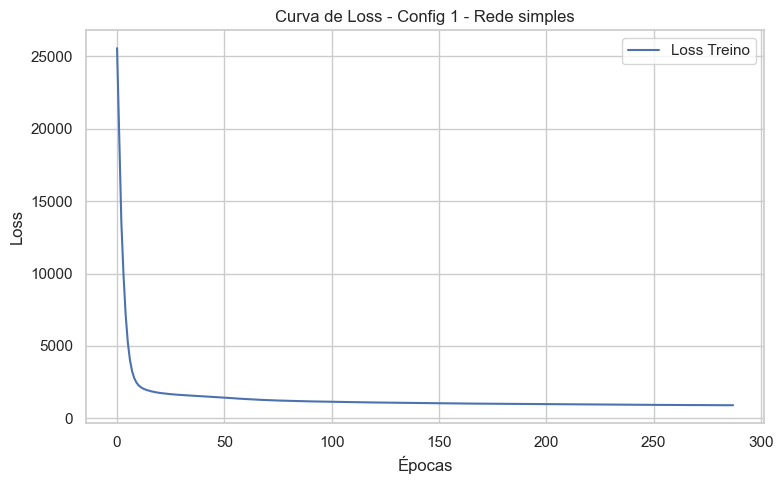

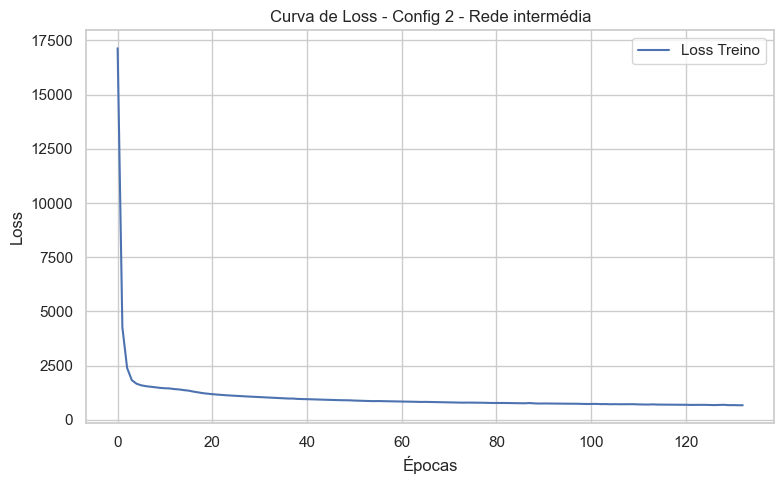

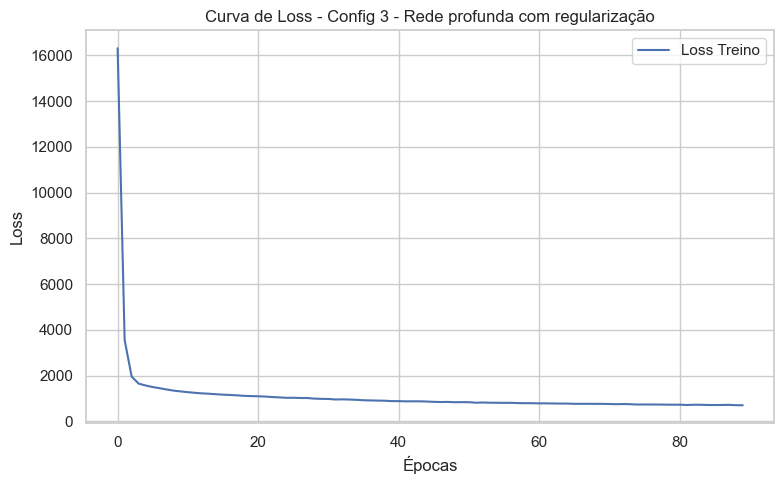

In [12]:
# ============================================================
# 4.2.3.d REDE NEURONAL PARA REGRESSÃO - MLPRegressor
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor

print("=" * 60)
print("4.2.3.d REDE NEURONAL - MLPRegressor")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes e alvo
# ------------------------------------------------------------

X = df_processed.drop(columns=["PFolga_PTD"]).astype(float)
y = df_processed["PFolga_PTD"]

# ------------------------------------------------------------
# Configurações a testar
# ------------------------------------------------------------

configs = [
    {
        "nome": "Config 1 - Rede simples",
        "hidden_layer_sizes": (32,),
        "alpha": 0.0001,
        "learning_rate_init": 0.001
    },
    {
        "nome": "Config 2 - Rede intermédia",
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.001,
        "learning_rate_init": 0.001
    },
    {
        "nome": "Config 3 - Rede profunda com regularização",
        "hidden_layer_sizes": (128, 64, 32),
        "alpha": 0.01,
        "learning_rate_init": 0.0005
    }
]

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_nn = []
historicos_loss = {}

# ------------------------------------------------------------
# Treino e avaliação das configurações
# ------------------------------------------------------------

rmse_nn_best = None

for config in configs:

    print("\n" + "=" * 60)
    print(config["nome"])
    print("=" * 60)

    mae_scores = []
    rmse_scores = []

    rmse_folds_config = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Standardização dentro do fold
        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = MLPRegressor(
            hidden_layer_sizes=config["hidden_layer_sizes"],
            activation="relu",
            solver="adam",
            alpha=config["alpha"],  # regularização L2
            learning_rate_init=config["learning_rate_init"],
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=15,
            random_state=42
        )

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        mae = mean_absolute_error(y_test, y_pred)

        rmse = np.sqrt(
            mean_squared_error(y_test, y_pred)
        )

        mae_scores.append(mae)
        rmse_scores.append(rmse)

        rmse_folds_config.append(rmse)

        print(
            f"Fold {fold} -> "
            f"MAE = {mae:.4f} | "
            f"RMSE = {rmse:.4f}"
        )

        # Guardar loss do primeiro fold para gráfico
        if fold == 1:
            historicos_loss[config["nome"]] = model.loss_curve_

    mae_medio = np.mean(mae_scores)
    rmse_medio = np.mean(rmse_scores)

    if config["nome"] == "Config 2 - Rede intermédia":
        rmse_nn_best = rmse_folds_config.copy()

    resultados_nn.append([
        config["nome"],
        config["hidden_layer_sizes"],
        config["alpha"],
        config["learning_rate_init"],
        mae_medio,
        rmse_medio
    ])

    print("-" * 60)
    print(f"MAE Médio : {mae_medio:.4f}")
    print(f"RMSE Médio: {rmse_medio:.4f}")

# ------------------------------------------------------------
# Resumo final
# ------------------------------------------------------------

resultados_nn = pd.DataFrame(
    resultados_nn,
    columns=[
        "Configuração",
        "Camadas",
        "Alpha L2",
        "Learning Rate",
        "MAE",
        "RMSE"
    ]
)

print("\nResumo das Redes Neuronais:")
print(resultados_nn)

melhor_nn = resultados_nn.loc[
    resultados_nn["RMSE"].idxmin()
]

print("\nMelhor configuração:")
print(melhor_nn)

# ------------------------------------------------------------
# Curvas de loss
# ------------------------------------------------------------

for nome_config, loss_curve in historicos_loss.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        loss_curve,
        label="Loss Treino"
    )

    plt.title(f"Curva de Loss - {nome_config}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

análise e interpretação de resultados da rede neuronal e curvas de loss

notas:

Análise das Curvas de Loss

As curvas de loss obtidas durante o treino da rede neuronal apresentam uma diminuição acentuada nas primeiras épocas, seguida de uma redução gradual até à estabilização. Este comportamento demonstra que a rede foi capaz de aprender rapidamente os padrões mais relevantes presentes nos dados, refinando posteriormente os seus parâmetros de forma progressiva.

Não foram observadas oscilações significativas, divergências ou comportamentos instáveis ao longo do treino, indicando que a learning rate selecionada foi adequada ao problema. A configuração intermédia, utilizando uma learning rate de 0.001, apresentou o melhor equilíbrio entre velocidade de convergência e qualidade da solução obtida.

Adicionalmente, a utilização do mecanismo de early stopping revelou-se eficaz, interrompendo automaticamente o treino quando deixaram de existir melhorias relevantes no desempenho de validação. Esta estratégia contribuiu para reduzir o risco de sobreajustamento e evitar tempos de treino desnecessariamente elevados.

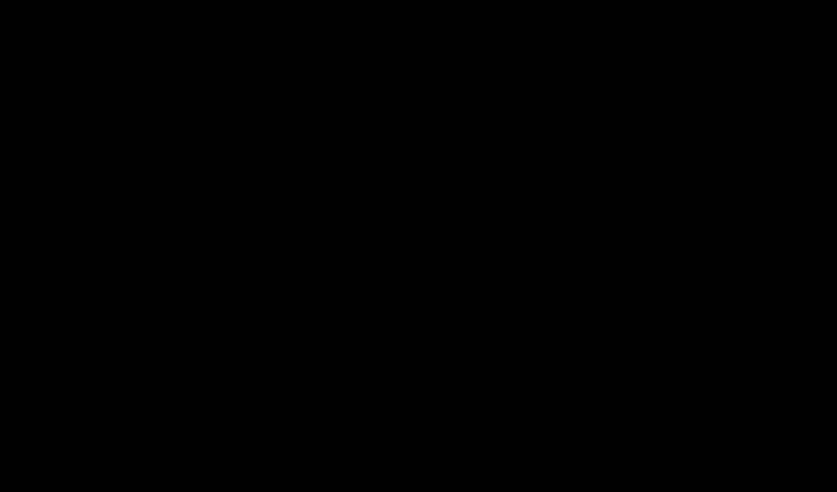
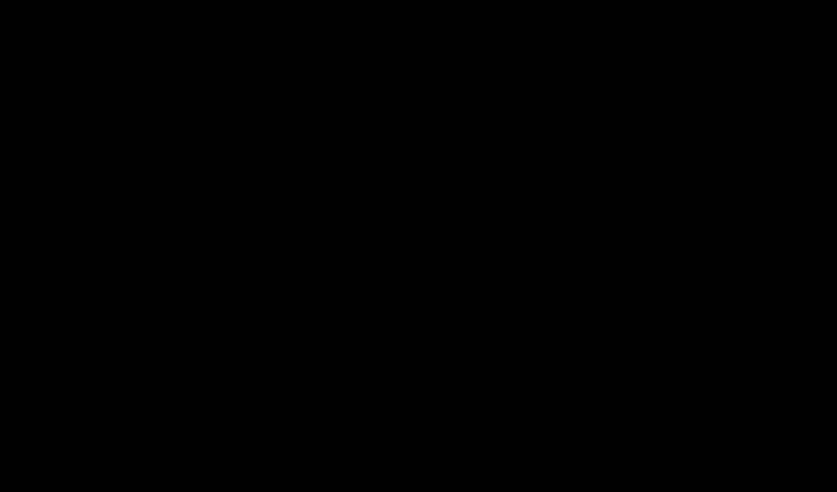

## 4.2.4 - Avaliação Comparativa dos Modelos de Regressão

Após o desenvolvimento dos diferentes modelos de regressão para previsão da variável **PFolga_PTD**, procedeu-se à comparação do seu desempenho através das métricas **Mean Absolute Error (MAE)** e **Root Mean Squared Error (RMSE)**. A avaliação foi realizada utilizando validação cruzada com 5 folds, permitindo obter uma estimativa mais robusta da capacidade de generalização de cada modelo.

## Comparação Global dos Modelos

| Modelo                             |       MAE |      RMSE |
| ---------------------------------- | --------: | --------: |
| Regressão Linear Simples           |     54.48 |     88.74 |
| Regressão Linear Múltipla          |     31.98 |     66.26 |
| SVR (Kernel Linear)                |     30.36 |     77.79 |
| Árvore de Regressão                |      8.63 |     49.54 |
| Rede Neuronal (Configuração 1)     |     14.10 |     47.37 |
| **Rede Neuronal (Configuração 2)** | **11.92** | **45.29** |
| Rede Neuronal (Configuração 3)     |     12.83 |     45.54 |

Observa-se que a **Regressão Linear Simples** apresentou o desempenho mais fraco, registando um RMSE médio de 88.74 e um MAE médio de 54.48. Este resultado era esperado, uma vez que o modelo utiliza apenas uma variável explicativa (*Cap_PTD_kVA*), não conseguindo capturar toda a complexidade das relações presentes nos dados.

A introdução de múltiplas variáveis explicativas permitiu melhorar significativamente o desempenho da **Regressão Linear Múltipla**, reduzindo o RMSE para 66.26. O modelo **SVM** com kernel linear apresentou um MAE semelhante, mas um RMSE superior, revelando menor capacidade preditiva para este problema.

Entre os modelos não lineares, a **Árvore de Regressão** apresentou uma melhoria relativamente aos modelos lineares, alcançando um RMSE médio de 49.54. Este resultado sugere a existência de relações não lineares entre as variáveis explicativas e a folga de potência disponível nos PTD.

O melhor desempenho global foi obtido pela **Rede Neuronal MLP (Configuração 2)**, composta por duas camadas ocultas com 64 e 32 neurónios, respetivamente. Este modelo atingiu um RMSE médio de 45.29 e um MAE médio de 11.92, apresentando a melhor capacidade preditiva entre todas as abordagens avaliadas.

De forma geral, os resultados demonstram que modelos capazes de capturar relações não lineares, nomeadamente **árvores de decisão** e **redes neuronais**, apresentam um desempenho superior aos modelos lineares tradicionais para a previsão da variável *PFolga_PTD*.

## Variáveis Mais Relevantes

A análise da importância das variáveis permitiu identificar os principais fatores que influenciam a folga de potência disponível nos postos de transformação.

| Variável           | Evidência                                                                    |
| ------------------ | ---------------------------------------------------------------------------- |
| Cap_PTD_kVA        | Variável mais importante na regressão múltipla e na árvore de regressão      |
| Util_Decimal       | Segunda variável mais importante na árvore e relevante na regressão múltipla |
| N_Luminarias       | Coeficiente elevado na regressão múltipla                                    |
| N_Lampadas         | Coeficiente elevado na regressão múltipla                                    |
| Pot_Contratada_kVA | Variável relevante na regressão múltipla                                     |

A variável **Cap_PTD_kVA** revelou-se o principal fator explicativo da folga disponível na rede. Esta variável apresentou o maior coeficiente na regressão linear múltipla e uma importância superior a 84% na árvore de regressão, demonstrando que a capacidade instalada do posto de transformação tem um impacto direto na potência disponível para acomodar novas cargas.

Adicionalmente, o **nível de utilização da rede** (*Util_Decimal*) destacou-se como a segunda variável mais influente, evidenciando que a capacidade disponível depende não apenas da potência instalada, mas também do grau de utilização atual do posto de transformação.

Por fim, variáveis relacionadas com a infraestrutura de iluminação pública, nomeadamente **N_Luminarias** e **N_Lampadas**, apresentaram coeficientes elevados na regressão múltipla, sugerindo que a dimensão da rede de iluminação pública influencia a capacidade remanescente disponível para integração de carregadores de veículos elétricos.


## 4.2.5 - Curvas de aprendizagem dos melhores modelos

Após a comparação dos modelos desenvolvidos, foram selecionados os dois modelos com melhor desempenho preditivo para análise das curvas de aprendizagem: a **Árvore de Regressão** e a **Rede Neuronal MLP (Configuração 2)**. O objetivo desta análise consiste em avaliar a capacidade de generalização dos modelos e identificar possíveis sinais de **overfitting** ou **underfitting**.

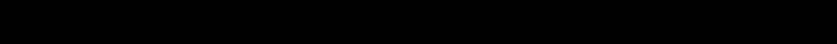

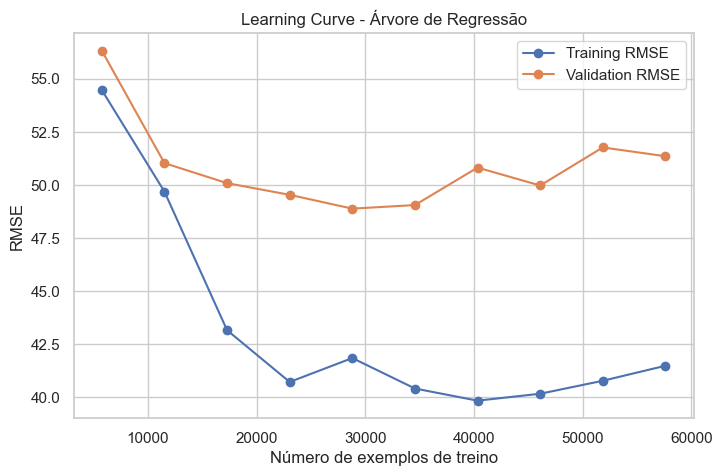

[106.19662511  88.11823371  81.08744033  78.06478922  79.8344366
  77.74789318  78.3822285   79.97556437  77.52216983  79.56007593]
[96.58225293 81.41628927 79.58238718 79.7882285  79.53878779 79.12610684
 79.81344794 79.78664755 79.41685536 80.41754093]


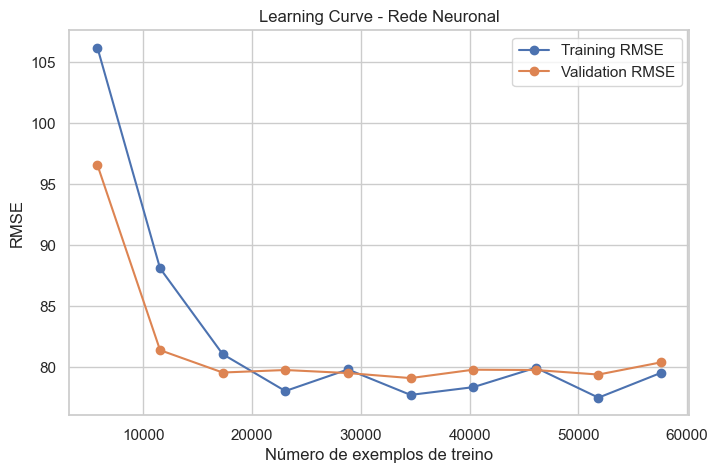

In [13]:
# ============================================================
# 4.2.5 CURVAS DE APRENDIZAGEM
# ============================================================

from sklearn.model_selection import learning_curve

tree_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    tree_model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_rmse,
    marker="o",
    label="Training RMSE"
)

plt.plot(
    train_sizes,
    val_rmse,
    marker="o",
    label="Validation RMSE"
)

plt.title("Learning Curve - Árvore de Regressão")
plt.xlabel("Número de exemplos de treino")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.show()

from sklearn.neural_network import MLPRegressor

nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    nn_model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_rmse,
    marker="o",
    label="Training RMSE"
)

plt.plot(
    train_sizes,
    val_rmse,
    marker="o",
    label="Validation RMSE"
)

plt.title("Learning Curve - Rede Neuronal")
plt.xlabel("Número de exemplos de treino")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

print(train_rmse)
print(val_rmse)

plt.show()

### Análise dos resultados

#### Árvore de Regressão

Observa-se que o erro de treino diminui progressivamente à medida que aumenta o número de exemplos utilizados para treino, evidenciando que o modelo beneficia da disponibilidade de mais dados.

O erro de validação apresenta igualmente uma tendência decrescente nas fases iniciais, estabilizando posteriormente em torno dos 50 pontos de RMSE. Embora exista uma diferença consistente entre as curvas de treino e validação, esta permanece relativamente reduzida ao longo de todo o processo de aprendizagem.

Este comportamento sugere a existência de um **ligeiro fenómeno de overfitting**, uma vez que o modelo apresenta um desempenho superior nos dados de treino relativamente aos dados de validação. No entanto, a diferença observada não é suficientemente elevada para comprometer a capacidade de generalização do modelo.

De forma geral, a Árvore de Regressão demonstra um processo de aprendizagem eficiente e uma boa capacidade preditiva para o problema em estudo.

#### Rede Neuronal MLP

Ao contrário da Árvore de Regressão, verifica-se uma convergência gradual entre as curvas de treino e validação à medida que aumenta o número de exemplos disponíveis. Para conjuntos de treino maiores, ambas as curvas apresentam valores muito próximos, indicando que o modelo mantém um desempenho semelhante em dados observados e não observados durante o treino.

Este comportamento evidencia uma **excelente capacidade de generalização**, não sendo observados sinais relevantes de overfitting nem de underfitting. A proximidade entre as curvas sugere que a complexidade do modelo se encontra ajustada à complexidade do problema.


#### Síntese dos Resultados

Em síntese, ambos os modelos apresentaram um processo de aprendizagem eficiente e uma capacidade satisfatória de generalização. Contudo, a Rede Neuronal MLP demonstrou um comportamento mais equilibrado, apresentando curvas de treino e validação muito próximas e ausência de sinais significativos de sobreajustamento.


# 4.2.6 Avaliação da Significância Estatística dos Resultados

Após a identificação dos dois modelos com melhor desempenho preditivo, procedeu-se à avaliação da significância estatística das diferenças observadas entre os respetivos resultados. Para tal, foram utilizados os valores de RMSE obtidos nos cinco folds da validação cruzada e aplicados dois testes estatísticos: o **teste t emparelhado** e o **teste não paramétrico de Wilcoxon Signed-Rank**.
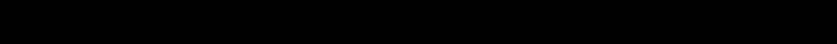

In [14]:
# ============================================================
# 4.2.6 TESTES ESTATÍSTICOS
# ============================================================

from scipy.stats import ttest_rel
from scipy.stats import wilcoxon

print("=" * 60)
print("4.2.6 TESTES ESTATÍSTICOS")
print("=" * 60)

# Teste t emparelhado

t_stat, p_value = ttest_rel(
    rmse_tree_folds,
    rmse_nn_best
)

print("\nTeste t emparelhado")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")

# Wilcoxon

w_stat, p_wilcoxon = wilcoxon(
    rmse_tree_folds,
    rmse_nn_best
)

print("\nTeste de Wilcoxon")
print(f"statistic = {w_stat:.4f}")
print(f"p-value = {p_wilcoxon:.4f}")

if p_value < 0.05:
    print("\nDiferença estatisticamente significativa (5%).")
else:
    print("\nDiferença NÃO estatisticamente significativa (5%).")


4.2.6 TESTES ESTATÍSTICOS

Teste t emparelhado
t-statistic = 2.4907
p-value = 0.0674

Teste de Wilcoxon
statistic = 1.0000
p-value = 0.1250

Diferença NÃO estatisticamente significativa (5%).



O teste t emparelhado obteve um valor de **p = 0.0674**, superior ao nível de significância adotado ($\alpha = 0.05$). De forma consistente, o teste de Wilcoxon produziu um valor de **p = 0.1250**, conduzindo à mesma conclusão.

Assim, para um nível de significância de 5%, não existe evidência estatística suficiente para rejeitar a hipótese nula de igualdade de desempenho entre os dois modelos, pois, embora a Rede Neuronal tenha apresentado o melhor desempenho médio, com um RMSE de 45.29 face aos 49.54 obtidos pela Árvore de Regressão, a diferença observada não se revelou estatisticamente significativa.

Estes resultados sugerem que ambos os modelos apresentam capacidades preditivas comparáveis para o problema em estudo. Consequentemente, não é possível afirmar, com 95% de confiança, que a Rede Neuronal seja efetivamente superior à Árvore de Regressão.

Em síntese, os testes estatísticos confirmam que os dois modelos constituem soluções competitivas para a previsão da variável **PFolga_PTD**, embora a Rede Neuronal apresente uma ligeira vantagem em termos de erro médio observado.
